In [13]:
import torch
from sklearn.model_selection import train_test_split
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [14]:
torch.manual_seed(42)

In [15]:
df = pd.read_csv('fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


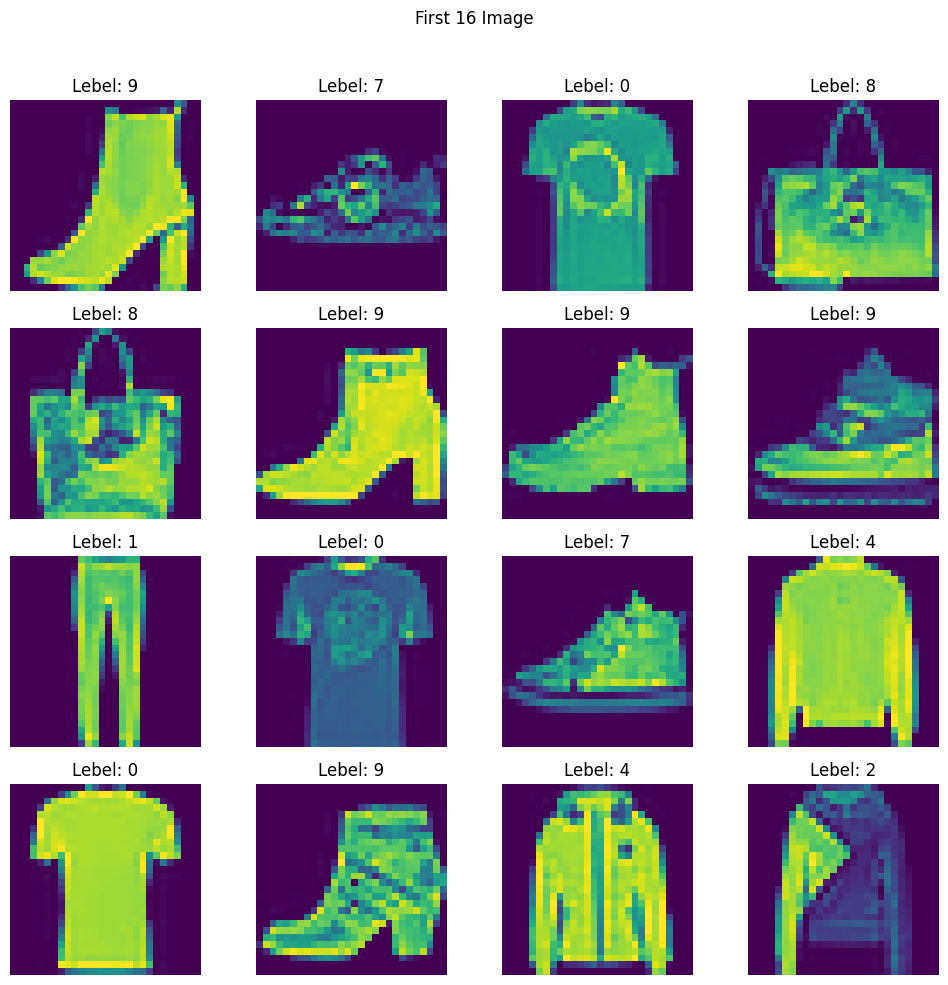

In [16]:
fig, axes =plt.subplots(4,4, figsize=(10,10))
fig.suptitle("First 16 Image")

for i,ax in enumerate(axes.flat):
    img = df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Lebel: {df.iloc[i,0]}")

plt.tight_layout(rect=[0,0,1,0.96])

plt.show()

In [17]:
X = df.iloc[:,1:]
y = df.iloc[:, 0]

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
X_train = X_train/255.0
X_test = X_test/255.0

In [22]:
#create customdataset class
from torch.utils.data import DataLoader,Dataset
class CustomDataset(Dataset):
    def __init__(self,features,labels):
        self.features = torch.tensor(features.values,dtype=torch.float32)
        self.labels = torch.tensor(labels.values,dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index],self.labels[index]

In [23]:
train_dataset = CustomDataset(X_train,y_train)

In [24]:
len(train_dataset)

4800

In [25]:
test_dataset = CustomDataset(X_test,y_test)

In [26]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

In [28]:
class MyNN(nn.Module):
    def __init__(self,num_featurs,):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_featurs,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )

    def forward(self,x):
        return self.model(x)

In [29]:
learning_rate = 0.1
epochs = 100

In [30]:
model = MyNN(X_train.shape[1])
criterian  = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),lr=learning_rate)

In [31]:
for epoch in range(epochs):

    total_epoch_loss = 0
    for batch_featurs,batch_labels in train_loader:
        #forward pass
        outputs = model(batch_featurs)

        #calculate loss
        loss = criterian(outputs,batch_labels)

        #backpass
        optimizer.zero_grad()
        loss.backward()

        #update grads
        optimizer.step()
        total_epoch_loss = total_epoch_loss + loss.item()

    avg_loss = total_epoch_loss/len(train_loader)
    print(f'Epoch: {epoch+1}, Loss: {avg_loss}')

Epoch: 1, Loss: 1.3216368456681569
Epoch: 2, Loss: 0.7793365393082301
Epoch: 3, Loss: 0.6427524596452713
Epoch: 4, Loss: 0.575165744026502
Epoch: 5, Loss: 0.5281801857550938
Epoch: 6, Loss: 0.49528749942779543
Epoch: 7, Loss: 0.4602432968219121
Epoch: 8, Loss: 0.43594590907295544
Epoch: 9, Loss: 0.418292143146197
Epoch: 10, Loss: 0.3976178348561128
Epoch: 11, Loss: 0.38594474136829376
Epoch: 12, Loss: 0.3714284903804461
Epoch: 13, Loss: 0.34849798401196797
Epoch: 14, Loss: 0.3495382188260555
Epoch: 15, Loss: 0.3174831034243107
Epoch: 16, Loss: 0.3095728649199009
Epoch: 17, Loss: 0.296412643690904
Epoch: 18, Loss: 0.2854420105119546
Epoch: 19, Loss: 0.2728715726733208
Epoch: 20, Loss: 0.2626084250956774
Epoch: 21, Loss: 0.26692370370030405
Epoch: 22, Loss: 0.2411968011657397
Epoch: 23, Loss: 0.24009631974001724
Epoch: 24, Loss: 0.22190598953515292
Epoch: 25, Loss: 0.22209177645544212
Epoch: 26, Loss: 0.21111380954583486
Epoch: 27, Loss: 0.21988285151620707
Epoch: 28, Loss: 0.21006234655

In [32]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [33]:
total = 0
correct = 0

with torch.no_grad():

    for batch_featurs,batch_labels in test_loader:
        outputs = model(batch_featurs)

        _,predicted = torch.max(outputs,1)
        total = total + batch_labels.shape[0]
        correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.83
